# Bio-inspired Batch Active Learning

This notebook demonstrates an active learning pipeline for image classification using the HAM10000 dataset (Skin Cancer MNIST). The goal is to improve model performance by strategically selecting the most informative samples to label from an unlabeled pool.

The pipeline includes:
- **Data Loading and Preprocessing**: Downloading and preparing the HAM10000 dataset.
- **Model Definition**: Setting up a ResNet18 model for image classification.
- **Training Loop**: Implementing a training and evaluation function.
- **Active Learning Strategies**: Exploring different query strategies (Random, Entropy, S-Score, S-Batch, NSGA-II) to select samples for labeling.
- **Experimentation**: Running active learning simulations and comparing the performance of different strategies.

In [ ]:
# Install KaggleHub for dataset access
!pip install kagglehub

# Import necessary libraries
import kagglehub
import pandas as pd
import torch
import torchvision.transforms as T
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random

In [ ]:
LOADER_BATCH_SCALE = 1

In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


## Download HAM10000

In [ ]:
from torchvision.datasets import ImageFolder

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Dataset downloaded to:", path)
DATA_DIR = "/kaggle/input/skin-cancer-mnist-ham10000"

images_part1 = DATA_DIR + "/HAM10000_images_part_1"
images_part2 = DATA_DIR + "/HAM10000_images_part_2"

!mkdir -p /content/ham10000/images
!cp -n /kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1/* /content/ham10000/images/
!cp -n /kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2/* /content/ham10000/images/

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset downloaded to: /kaggle/input/skin-cancer-mnist-ham10000


In [ ]:
from pathlib import Path

meta_path = "/kaggle/input/skin-cancer-mnist-ham10000//HAM10000_metadata.csv"
df = pd.read_csv(meta_path)

img_dir = Path("/content/ham10000/images")
df["path"] = df["image_id"].apply(lambda x: str(img_dir / f"{x}.jpg"))

# sanity check: keep only rows where file exists
df = df[df["path"].apply(lambda p: Path(p).exists())].reset_index(drop=True)

df = df[["image_id", "dx", "path"]]
df.head(), df["dx"].value_counts()

(       image_id   dx                                       path
 0  ISIC_0027419  bkl  /content/ham10000/images/ISIC_0027419.jpg
 1  ISIC_0025030  bkl  /content/ham10000/images/ISIC_0025030.jpg
 2  ISIC_0026769  bkl  /content/ham10000/images/ISIC_0026769.jpg
 3  ISIC_0025661  bkl  /content/ham10000/images/ISIC_0025661.jpg
 4  ISIC_0031633  bkl  /content/ham10000/images/ISIC_0031633.jpg,
 dx
 nv       6705
 mel      1113
 bkl      1099
 bcc       514
 akiec     327
 vasc      142
 df        115
 Name: count, dtype: int64)

In [ ]:
from sklearn.model_selection import train_test_split

label2id = {lbl:i for i,lbl in enumerate(sorted(df["dx"].unique()))}
id2label = {v:k for k,v in label2id.items()}
df["y"] = df["dx"].map(label2id)

# stratify=df["y"] ensures that the class distribution is preserved in both sets
train_df, test_df = train_test_split(df, test_size=0.15, stratify=df["y"], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df["y"], random_state=42)

# print the lengths of the resulting dataframes and the label-to-ID mapping
len(train_df), len(val_df), len(test_df), label2id

(7235,
 1277,
 1503,
 {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6})

## Define Training Model

### Define Dataset

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

train_tfms = T.Compose([
    T.Resize((224,224)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.05, 0.05, 0.05, 0.02),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

eval_tfms = T.Compose([
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

class HamDataset(Dataset):
    def __init__(self, df, tfms):
        self.df = df.reset_index(drop=True)
        self.tfms = tfms
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        x = self.tfms(img)
        y = int(row["y"])
        return x, y

### Define Model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def make_model(num_classes):
    # load a pre-trained ResNet18 model with ImageNet weights
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m.to(device)

# calculate class weights to handle potential class imbalance
# counts: number of samples per class in the training data
counts = train_df["y"].value_counts().sort_index().values
# weights: inverse of class frequency, higher for less frequent classes
weights = 1.0 / torch.tensor(counts, dtype=torch.float)
weights = (weights / weights.mean()).to(device)

model = make_model(len(label2id))
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 219MB/s]


### Training Mode(s)

Given the small and evolving labeled set in early active learning rounds, we adopt a freeze–unfreeze training strategy. The backbone is initially frozen to stabilize optimization and prevent overfitting, and subsequently unfrozen to allow feature adaptation once the classifier head has converged. This significantly reduces training variance and ensures fair comparison between acquisition strategies.

In [ ]:
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm

def run_epoch(model, loader, train=True, optimizer=None, criterion=None):
    model.train(train)
    all_y, all_p = [], []
    total_loss = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)

        all_y.append(y.detach().cpu().numpy())
        all_p.append(preds.detach().cpu().numpy())

    all_y = np.concatenate(all_y)
    all_p = np.concatenate(all_p)

    # calculate accuracy and macro F1-score for the epoch
    acc = accuracy_score(all_y, all_p)
    f1  = f1_score(all_y, all_p, average="macro")
    # return average loss, accuracy, and F1-score
    return total_loss / len(loader.dataset), acc, f1

In [ ]:
import copy

# Trains the model using a two-phase transfer learning strategy.
# Phase 1: freeze the pretrained backbone and train only the classification head
# to stabilize learning with a small labeled set.

# Phase 2: unfreeze the backbone and fine-tune the full network with a lower
# learning rate to adapt features to the target task.
# Uses early stopping based on validation macro-F1 to prevent overfitting.

def freeze_backbone(model):
    # freeze all parameters in the model
    for p in model.parameters():
        p.requires_grad = False
    # unfreeze only the classifier head (final fully connected layer) for training
    for p in model.fc.parameters():
        p.requires_grad = True

def unfreeze_all(model):
    # unfreeze all parameters in the model to allow full fine-tuning
    for p in model.parameters():
        p.requires_grad = True

def train_freeze_unfreeze(model, L_loader, V_loader,
      epochs_frozen=3, epochs_unfrozen=7,
      lr_frozen=1e-3, lr_unfrozen=3e-4,
      weight_decay=1e-2, patience=3):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    # store the best model state and F1 score for early stopping
    best_state = copy.deepcopy(model.state_dict())
    best_f1 = -1.0
    bad = 0

    # Phase A: train only the classifier head (backbone frozen)
    freeze_backbone(model)
    # optimizer for only the classifier head parameters
    optimizer = torch.optim.AdamW(model.fc.parameters(), lr=lr_frozen, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs_frozen))

    print("\nStarting Phase A: Training with frozen backbone (classifier head only)")
    for epoch in range(epochs_frozen):
        # run one training epoch and one validation epoch
        tr_loss, tr_acc, tr_f1 = run_epoch(model, L_loader, train=True,  optimizer=optimizer, criterion=criterion)
        va_loss, va_acc, va_f1 = run_epoch(model, V_loader, train=False, optimizer=None,     criterion=criterion)
        scheduler.step()

        print(f"[FROZEN] ep {epoch:02d} | tr {tr_loss:.4f} {tr_acc:.3f} {tr_f1:.3f} | va {va_loss:.4f} {va_acc:.3f} {va_f1:.3f}")

        # early stopping logic
        if va_f1 > best_f1 + 1e-4:
            best_f1 = va_f1
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stopping in Phase A after {patience} epochs without improvement.")
                break

    # Phase B: Fine-tune all layers (unfrozen backbone)
    unfreeze_all(model)
    # optimizer for all model parameters
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_unfrozen, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs_unfrozen))
    bad = 0

    print("\nStarting Phase B: Fine-tuning all layers (unfrozen backbone)")
    for epoch in range(epochs_unfrozen):
        tr_loss, tr_acc, tr_f1 = run_epoch(model, L_loader, train=True,  optimizer=optimizer, criterion=criterion)
        va_loss, va_acc, va_f1 = run_epoch(model, V_loader, train=False, optimizer=None,     criterion=criterion)
        scheduler.step()

        print(f"[UNFROZE] ep {epoch:02d} | tr {tr_loss:.4f} {tr_acc:.3f} {tr_f1:.3f} | va {va_loss:.4f} {va_acc:.3f} {va_f1:.3f}")

        if va_f1 > best_f1 + 1e-4:
            best_f1 = va_f1
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stopping in Phase B after {patience} epochs without improvement.")
                break

    model.load_state_dict(best_state)
    return model, best_f1

### Define Loaders

In [ ]:
from torch.utils.data import WeightedRandomSampler

# WeightedRandomSampler draws samples with probability inversely proportional
# to class frequency, ensuring that rare classes are seen more often during
# training --> reduces bias toward majority classes without modifying the
# loss function or the dataset.

def make_weighted_sampler(df_subset, num_classes):
    y = df_subset["y"].to_numpy()
    class_counts = np.bincount(y, minlength=num_classes)
    class_counts = np.clip(class_counts, 1, None)
    class_w = 1.0 / class_counts
    sample_w = class_w[y]
    sample_w = torch.tensor(sample_w, dtype=torch.double)
    return WeightedRandomSampler(weights=sample_w, num_samples=len(sample_w), replacement=True)

def make_train_loader(df_subset, batch_size=64, num_workers=2):
    batch_size = batch_size * LOADER_BATCH_SCALE
    ds = HamDataset(df_subset, tfms=train_tfms)
    sampler = make_weighted_sampler(df_subset, num_classes=len(label2id))
    return DataLoader(ds, batch_size=batch_size, sampler=sampler,
                      num_workers=num_workers, pin_memory=True)

def make_eval_loader(df_subset, batch_size=128, num_workers=2):
    batch_size = batch_size * LOADER_BATCH_SCALE
    ds = HamDataset(df_subset, tfms=eval_tfms)
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                      num_workers=num_workers, pin_memory=True)

## Define Embedder

These utilities extract uncertainty and embedding-based geometry information required to construct single- and multi-objective batch acquisition functions.


In [ ]:
class ResNet18Embedder(nn.Module):
    '''
    Wrapper around a ResNet-18 classifier that exposes the feature extractor
    (all layers except the final classification head) -->
    produces 512-dimensional, L2-normalized embeddings suitable for distance-
    based comparisons used in diversity and representativeness objectives.
    '''
    def __init__(self, clf_model):  # clf_model is the resnet18 with fc replaced
        super().__init__()
        # everything except the final fc
        self.backbone = nn.Sequential(*list(clf_model.children())[:-1])  # ends with avgpool
    def forward(self, x):
        z = self.backbone(x) # [B, 512, 1, 1]
        z = z.flatten(1)     # [B, 512]
        z = F.normalize(z, dim=1) # helpful for cosine/Euclidean comparisons
        return z

@torch.no_grad()
def extract_embeddings(model, df_subset, batch_size=128):
    '''
    Extracts feature embeddings for all samples in a dataset subset -->
    runs the model in evaluation mode and returns a tensor of shape [N, 512],
    where each row corresponds to the normalized embedding of one image.
    '''
    model.eval()
    embedder = ResNet18Embedder(model).to(device)
    loader = make_eval_loader(df_subset, batch_size=batch_size)

    Z = []
    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        z = embedder(x).detach().cpu()
        Z.append(z)
    return torch.cat(Z, dim=0)  # [N, 512]

@torch.no_grad()
def predictive_entropy(model, df_subset, batch_size=128):
    '''
    Computes predictive entropy for each sample in a dataset subset
    (uses the softmax output of the classifier as a measure of model uncertainty).
    '''
    model.eval()
    loader = make_eval_loader(df_subset, batch_size=batch_size)

    ent = []
    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        p = torch.softmax(logits, dim=1)
        e = -(p * (p.clamp_min(1e-9).log())).sum(dim=1)  # [B]
        ent.append(e.cpu())
    return torch.cat(ent, dim=0)  # [N]

@torch.no_grad()
def min_dist_to_set(Z_A, Z_B, chunk=2048):
    '''
    Computes, for each embedding in Z_A, the minimum Euclidean distance to
    any embedding in Z_B.
    '''
    # returns for each row in A: min_j ||A_i - B_j||
    mins = []
    for i in range(0, Z_A.size(0), chunk):
        d = torch.cdist(Z_A[i:i+chunk], Z_B)         # [chunk, |B|]
        mins.append(d.min(dim=1).values.cpu())
    return torch.cat(mins, dim=0)

# nearest neighbor distance within U
@torch.no_grad()
def approx_nn_dist_to_subset(Z, subset_idx, chunk=2048):
  '''
  Approximates nearest-neighbor distances to a subset of embeddings.
  '''
  # For each z in Z, compute min dist to Z[subset_idx]
  Z_sub = Z[subset_idx]
  mins = []
  for i in range(0, Z.size(0), chunk):
      d = torch.cdist(Z[i:i+chunk], Z_sub)
      mins.append(d.min(dim=1).values.cpu())
  return torch.cat(mins, dim=0)

def robust_01(t, lo=5, hi=95):
    '''
    Robustly rescales a 1D tensor to the [0, 1] range using percentile clipping.
    '''
    # t: 1D torch tensor on CPU or GPU
    t = t.detach().float().cpu().numpy()
    a = np.percentile(t, lo)
    b = np.percentile(t, hi)
    out = (t - a) / (b - a + 1e-9)
    out = np.clip(out, 0.0, 1.0)
    return torch.from_numpy(out)

## NSGA-2 Implementation

In [ ]:
@torch.no_grad()
def nsga_prepare(model, L_df, U_df, B=50, M=500, seed=0, delta_f1=None, round=0, rounds=1):
    model.eval()

    M_eff = min(M, len(U_df))
    B_eff = min(B, M_eff)

    # 1) entropy for all U, choose top-M as candidate pool
    U_unc_all = predictive_entropy(model, U_df, batch_size=256).cpu()  # [|U|]
    cand_pos = torch.topk(U_unc_all, k=M_eff).indices.cpu().numpy()
    U_cand = U_df.iloc[cand_pos]

    # 2) embeddings for candidates and labeled
    Zc = extract_embeddings(model, U_cand, batch_size=256).cpu()  # [M,d]
    ZL = extract_embeddings(model, L_df, batch_size=256).cpu()

    # 3) distance-to-labeled for each candidate
    DL = min_dist_to_set(Zc, ZL, chunk=2048).cpu()  # [M]

    # 4) normalize pointwise terms
    U_n  = robust_01(U_unc_all[cand_pos].cpu())
    DL_n = robust_01(DL)

    return {
        "U_cand": U_cand,
        "cand_pos": cand_pos,
        "U_n": U_n.float(),
        "DL_n": DL_n.float(),
        "Zc": Zc.float(),
        "B": B_eff,
        "seed": seed,
        "delta_f1": delta_f1,
        "round": round,
        "rounds": rounds
    }

@torch.no_grad()
def batch_objectives(ind, prep):
    U_n = prep["U_n"]
    DL_n = prep["DL_n"]
    Zc = prep["Zc"]

    idx = torch.from_numpy(ind).long()

    f1 = U_n[idx].mean().item()
    f2 = DL_n[idx].mean().item()

    Z = Zc[idx]  # [B,d]
    Z = F.normalize(Z, dim=1)

    if Z.shape[0] > 40:
        g = torch.Generator(device=Z.device)
        g.manual_seed(int(idx.sum().item()) % (2**31 - 1))
        perm = torch.randperm(Z.shape[0], generator=g, device=Z.device)[:40]
        Z = Z[perm]

    f3 = torch.pdist(Z).mean().item() if Z.shape[0] >= 2 else 0.0

    return (f1, f2, f3)

#### Non-dominated Sort and Crowding Distance

In [ ]:
def dominates(a,b):
    return all(x>=y for x,y in zip(a,b)) and any(x>y for x,y in zip(a,b))

def fast_nondominated_sort(F):
    S = [[] for _ in range(len(F))]
    n = [0]*len(F)
    fronts = [[]]

    for p in range(len(F)):
        for q in range(len(F)):
            if p == q:
                continue
            if dominates(F[p], F[q]):
                S[p].append(q)
            elif dominates(F[q], F[p]):
                n[p] += 1
        if n[p] == 0:
            fronts[0].append(p)

    i = 0
    while fronts[i]:
        nxt = []
        for p in fronts[i]:
            for q in S[p]:
                n[q] -= 1
                if n[q] == 0:
                    nxt.append(q)
        i += 1
        fronts.append(nxt)

    return fronts[:-1]

def crowding_distance(front, F):
    if len(front) == 0:
        return {}
    m = len(F[0])
    dist = {i: 0.0 for i in front}

    for k in range(m):
        front_sorted = sorted(front, key=lambda i: F[i][k])
        dist[front_sorted[0]] = float("inf")
        dist[front_sorted[-1]] = float("inf")
        fmin = F[front_sorted[0]][k]
        fmax = F[front_sorted[-1]][k]
        denom = (fmax - fmin) if (fmax - fmin) > 1e-12 else 1e-12

        for j in range(1, len(front_sorted)-1):
            prevv = F[front_sorted[j-1]][k]
            nextv = F[front_sorted[j+1]][k]
            dist[front_sorted[j]] += (nextv - prevv) / denom

    return dist

#### Genetic Operators

In [ ]:
def init_individual(M, B, rng):
    if B >= M:
        return np.arange(M, dtype=np.int32)
    return np.array(rng.choice(M, size=B, replace=False), dtype=np.int32)

def crossover_set(a, b, M, B, rng):
    u = np.unique(np.concatenate([a, b]))
    if len(u) >= B:
        child = rng.choice(u, size=B, replace=False)
    else:
        remaining = np.setdiff1d(np.arange(M), u, assume_unique=False)
        need = B - len(u)
        if need > 0 and len(remaining) > 0:
            need = min(need, len(remaining))
            fill = rng.choice(remaining, size=need, replace=False)
            child = np.concatenate([u, fill])
        else:
            child = u
    return child.astype(np.int32)

def mutate_set(ind, M, B, rng, p=0.2):
    ind = ind.copy()
    if rng.random() > p:
        return ind

    # If batch already uses all candidates, cannot replace anything
    available = np.setdiff1d(np.arange(M), ind, assume_unique=False)
    if len(available) == 0:
        return ind  # no feasible mutation

    k = max(1, int(0.1 * B))
    k = min(k, len(available), len(ind))  # keep feasible

    replace_pos = rng.choice(len(ind), size=k, replace=False)
    new_vals = rng.choice(available, size=k, replace=False)
    ind[replace_pos] = new_vals

    ind = np.unique(ind)
    if len(ind) < B:
        available = np.setdiff1d(np.arange(M), ind, assume_unique=False)
        need = B - len(ind)
        if need > 0:
            need = min(need, len(available))
            if need > 0:
                fill = rng.choice(available, size=need, replace=False)
                ind = np.concatenate([ind, fill])
    return ind.astype(np.int32)

#### Batch Selection

In [ ]:
def nsga2_select_batch(prep, pop_size=40, gens=25, cx_rate=0.9, mut_rate=0.3, seed=0, chooser="sum"):
    '''
    Runs the NSGA-II evolutionary loop to optimize a population of candidate
    batches under multiple acquisition objectives, returning a Pareto-optimal
    batch for active learning.
    '''
    rng = np.random.default_rng(seed)
    M = len(prep["U_cand"])
    B = int(prep["B"])
    B = min(B, M)
    print(f"[nsga2_select_batch] M={M}, B={B}")

    # init population
    pop = [init_individual(M, B, rng) for _ in range(pop_size)]

    def evaluate_population(pop):
        return [batch_objectives(ind, prep) for ind in pop]

    F = evaluate_population(pop)

    for g in range(gens):
        # --- create offspring ---
        offspring = []
        while len(offspring) < pop_size:
            # tournament selection on rank+crowding
            fronts = fast_nondominated_sort(F)
            rank = {}
            for i, fr in enumerate(fronts):
                for idx in fr:
                    rank[idx] = i
            crowd = {}
            for fr in fronts:
                crowd.update(crowding_distance(fr, F))

            def tournament():
                i, j = rng.integers(0, pop_size), rng.integers(0, pop_size)
                if rank[i] < rank[j]:
                    return pop[i]
                if rank[j] < rank[i]:
                    return pop[j]
                # tie -> crowding
                return pop[i] if crowd[i] > crowd[j] else pop[j]

            p1, p2 = tournament(), tournament()

            if rng.random() < cx_rate:
                child = crossover_set(p1, p2, M, B, rng)
            else:
                child = p1.copy()

            child = mutate_set(child, M, B, rng, p=mut_rate)
            offspring.append(child)

        # combine and select next gen
        combined = pop + offspring
        F_comb = [batch_objectives(ind, prep) for ind in combined]

        fronts = fast_nondominated_sort(F_comb)

        new_pop = []
        new_F = []
        for fr in fronts:
            if len(new_pop) + len(fr) <= pop_size:
                for idx in fr:
                    new_pop.append(combined[idx])
                    new_F.append(F_comb[idx])
            else:
                # fill remainder by crowding distance
                cd = crowding_distance(fr, F_comb)
                fr_sorted = sorted(fr, key=lambda i: cd[i], reverse=True)
                for idx in fr_sorted[:(pop_size - len(new_pop))]:
                    new_pop.append(combined[idx])
                    new_F.append(F_comb[idx])
                break

        pop, F = new_pop, new_F

    # final Pareto front
    fronts = fast_nondominated_sort(F)
    pareto = fronts[0]

    # pick one solution
    vals = np.array([F[i] for i in pareto], dtype=np.float32)

    F_all = np.array(F, dtype=np.float32)  # stable within this round
    mins = F_all.min(axis=0)
    maxs = F_all.max(axis=0)
    vals_n = (vals - mins) / (maxs - mins + 1e-9)
    vals_n = np.clip(vals_n, 0.0, 1.0)

    weights = None

    if chooser == "sum":
        scores = vals_n.sum(axis=1)

    elif chooser == "ideal":
        ideal = np.ones(vals_n.shape[1], dtype=np.float32)
        scores = -np.linalg.norm(vals_n - ideal, axis=1)  # closer to ideal is better

    elif chooser == "maximin":
        scores = vals_n.min(axis=1)  # maximize worst objective

    elif chooser == "adaptive":
        t = int(prep.get("round", 0))
        T = int(prep.get("rounds", 1))
        frac = t / max(1, T)

        # exploit-heavy -> balanced (fine)
        wU = 0.70*(1-frac) + 0.40*frac
        wC = 0.20*(1-frac) + 0.35*frac
        wD = 0.10*(1-frac) + 0.25*frac

        delta = prep.get("delta_f1", None)
        if delta is not None:
            # if delta < 0.01, gradually increase explore weights (no hard jump)
            boost = float(np.clip((0.01 - delta)/0.01, 0.0, 1.0))  # 0..1
            wC += 0.15*boost
            wD += 0.15*boost
            wU -= 0.30*boost

        # keep uncertainty from collapsing
        wU = max(wU, 0.40)

        # renormalize
        s = wU + wC + wD
        wU, wC, wD = wU/s, wC/s, wD/s

        weights = (float(wU), float(wC), float(wD))
        scores = wU*vals_n[:,0] + wC*vals_n[:,1] + wD*vals_n[:,2]

    else:
        raise ValueError(f"Unknown chooser: {chooser}")

    cd = crowding_distance(pareto, F)  # returns dict over indices in pop

    best_score = np.max(scores)
    top = [pareto[i] for i in np.where(scores >= best_score - 1e-6)[0]]  # indices in pop

    # choose most isolated among ties
    best_idx = max(top, key=lambda idx: cd.get(idx, -1.0))

    best_ind = pop[best_idx]
    best_obj = F[best_idx]
    return best_ind, best_obj, weights

In [ ]:
def nsga2_all_batch(prep, pop_size=40, gens=25, cx_rate=0.9, mut_rate=0.3, seed=0):
    """
    Runs the NSGA-II evolutionary loop to optimize a population of candidate batches
    under multiple acquisition objectives, returning a Pareto-optimal batch for active learning.

    Returns:
        F (list): objective vectors for the final population
        pareto (list[int]): indices of individuals on the final Pareto front (w.r.t. final population)
        best_ind: chosen batch (one of the Pareto-front individuals)
        best_obj: objective vector for best_ind
    """
    rng = np.random.default_rng(seed)

    M = len(prep["U_cand"])
    B = prep["B"]

    # init population
    pop = [init_individual(M, B, rng) for _ in range(pop_size)]

    def evaluate_population(p):
        return [batch_objectives(ind, prep) for ind in p]

    all_objs = []
    F = evaluate_population(pop)
    all_objs.extend(F)

    for _g in range(gens):
        # --- create offspring ---
        fronts = fast_nondominated_sort(F)

        # rank map
        rank = {}
        for i, fr in enumerate(fronts):
            for idx in fr:
                rank[idx] = i

        # crowding distances for current population
        crowd = {}
        for fr in fronts:
            crowd.update(crowding_distance(fr, F))

        def tournament():
            i = int(rng.integers(0, pop_size))
            j = int(rng.integers(0, pop_size))

            if rank[i] < rank[j]:
                return pop[i]
            if rank[j] < rank[i]:
                return pop[j]
            # tie -> crowding
            return pop[i] if crowd[i] > crowd[j] else pop[j]

        offspring = []
        while len(offspring) < pop_size:
            p1, p2 = tournament(), tournament()

            if rng.random() < cx_rate:
                child = crossover_set(p1, p2, M, B, rng)
            else:
                child = p1.copy()

            child = mutate_set(child, M, B, rng, p=mut_rate)
            offspring.append(child)

        # combine and select next gen
        combined = pop + offspring
        F_comb = [batch_objectives(ind, prep) for ind in combined]
        all_objs.extend(F_comb)
        fronts = fast_nondominated_sort(F_comb)

        new_pop = []
        new_F = []

        for fr in fronts:
            if len(new_pop) + len(fr) <= pop_size:
                for idx in fr:
                    new_pop.append(combined[idx])
                    new_F.append(F_comb[idx])
            else:
                # fill remainder by crowding distance within this front
                cd = crowding_distance(fr, F_comb)
                fr_sorted = sorted(fr, key=lambda i: cd[i], reverse=True)
                remaining = pop_size - len(new_pop)
                for idx in fr_sorted[:remaining]:
                    new_pop.append(combined[idx])
                    new_F.append(F_comb[idx])
                break

        pop, F = new_pop, new_F

    # final Pareto front (of final population)
    fronts = fast_nondominated_sort(F)
    pareto = fronts[0]

    # pick one solution: maximize normalized sum as a simple “knee-ish” choice
    vals = np.array([F[i] for i in pareto], dtype=np.float32)
    vals_n = (vals - vals.min(axis=0)) / (vals.max(axis=0) - vals.min(axis=0) + 1e-9)
    scores = vals_n.sum(axis=1)

    best_idx = pareto[int(np.argmax(scores))]
    best_ind = pop[best_idx]
    best_obj = F[best_idx]

    return F, pareto, best_ind, best_obj, all_objs

## MOPSO Implementation

In this section, we apply **Multi-Objective Particle Swarm Optimization (MOPSO)** to learn a selection rule for unlabeled data.

Each **particle** represents a **selection rule**, rather than a set of sample indices.

This is necessary because *sample indices* define a discrete and combinatorial search space, which is not well suited for PSO.

By optimizing a rule, we instead operate in a continuous space, where PSO can effectively update particle positions using velocity-based dynamics.

---

Let's define some **utility functions** used to handle Pareto dominance in the multi-objective setting.


In [ ]:
def dominates(obj_a, obj_b):
    return all(a >= b for a, b in zip(obj_a, obj_b)) and any(a > b for a, b in zip(obj_a, obj_b))

def pareto_front_indices(objectives):
    """
    Returns the indices of the non-dominated solutions in the objectives list.
    """
    keep = []
    for i, obj_i in enumerate(objectives):
        dominated = any(
            dominates(objectives[j], obj_i)
            for j in range(len(objectives)) if j != i
        )
        if not dominated:
            keep.append(i)
    return keep

This step restricts the search to the most uncertain samples and represents them through continuous objective values, enabling efficient MOPSO optimization.


In [ ]:
@torch.no_grad()
def prepare_mopso_candidates(model, labeled_df, unlabeled_df, batch_size=50, num_candidates=500):
    """
    Prepares candidate samples from the unlabeled dataset for MOPSO
    active learning by computing uncertainty and novelty scores.
    """
    model.eval()

    # Computing uncertainty for all unlabeled samples
    uncertainty_all = predictive_entropy(model, unlabeled_df, batch_size=256).cpu()

    # Selecting top-M uncertain samples as candidates
    M = min(num_candidates, len(unlabeled_df))
    candidate_positions = torch.topk(uncertainty_all, k=M).indices.cpu().numpy()
    candidate_df = unlabeled_df.iloc[candidate_positions]

    # Getting Embeddings
    Z_candidates = extract_embeddings(model, candidate_df, batch_size=256).cpu()
    Z_labeled = extract_embeddings(model, labeled_df, batch_size=256).cpu()

    # Novelty = minimum distance to labeled samples
    novelty = min_dist_to_set(Z_candidates, Z_labeled)

    # Normalization
    uncertainty_norm = robust_01(uncertainty_all[candidate_positions]).float()
    novelty_norm = robust_01(novelty).float()

    return {
        "candidate_df": candidate_df,
        "candidate_positions": candidate_positions,
        "uncertainty": uncertainty_norm,
        "novelty": novelty_norm,
        "embeddings": Z_candidates.float(),
        "B": batch_size,
        "M": M,
    }

This a crucial function, it is the mapping btw scores &rarr; batch indices and it converts a **scoring rule** into a concrete **batch** (indices) by selecting the top-B highest-scoring candidates.


In [ ]:
def scores_to_batch_indices(candidate_scores, B):
    """
    Transforms a scoring rule into a batch of B indices.
    """
    return np.argsort(-candidate_scores)[:B]

The batch is scored by averaging uncertainty and novelty, while diversity is measured as the mean distance from the batch centroid in embedding space.


In [ ]:
def evaluate_batch(batch_indices, prep):
    """
    Computes (uncertainty, novelty, diversity) of a batch.
    """
    idx = torch.from_numpy(batch_indices).long()

    # f1: uncertainty
    f_uncertainty = prep["uncertainty"][idx].mean().item()

    # f2: novelty
    f_novelty = prep["novelty"][idx].mean().item()

    # f3: diversity
    Z = prep["embeddings"][idx]
    centroid = Z.mean(dim=0, keepdim=True)
    f_diversity = torch.norm(Z - centroid, dim=1).mean().item()

    return (f_uncertainty, f_novelty, f_diversity)

Each scoring rule produces *one score* per candidate (M scores), which are ranked to select a batch of size B.

In [ ]:
def evaluate_scoring_rule(candidate_scores, prep):
    """
    From a particle (scoring rule) → batch → objectives.
    """
    batch_indices = scores_to_batch_indices(candidate_scores, prep["B"])
    objectives = evaluate_batch(batch_indices, prep)
    return objectives, batch_indices

Runs **Multi-Objective PSO** to optimize a population of scoring rules and select a batch of unlabeled samples from the Pareto-optimal solutions.

Particles evolve as continuous scoring rules: at each iteration they are evaluated through batch-level objectives and stored in a Pareto archive.



In [ ]:
def mopso_select_batch(prep,swarm_size=40, iterations=30, w_max=0.9, w_min =0.4, c1=1.4, c2=1.4, seed=0, return_archive=False):

    rng = np.random.default_rng(seed)
    M = prep["M"]

    # Initiatization of particles (scoring rules)
    particles = [rng.normal(0, 0.1, size=M).astype(np.float32) for _ in range(swarm_size)]
    velocities = [np.zeros(M, dtype=np.float32) for _ in range(swarm_size)]

    # Personal best
    pbest_particles = particles.copy()
    pbest_objectives = []
    pbest_batches = []

    for p in particles:
        obj, batch = evaluate_scoring_rule(p, prep)
        pbest_objectives.append(obj)
        pbest_batches.append(batch)

    # Pareto archive
    pareto_particles = pbest_particles.copy()
    pareto_objectives = pbest_objectives.copy()
    pareto_batches = pbest_batches.copy()

    # Tracking all objectives
    all_objectives = pbest_objectives.copy()


    # PSO loop
    for iteration in range(iterations):

        # inertia weight scheduling
        w = w_max - (w_max - w_min) * (iteration / iterations)

        # LOGGING in case
        #print(f"Iteration {iteration}: w = {w:.4f}")

        pareto_idx = pareto_front_indices(pareto_objectives)
        gbest_idx = rng.choice(pareto_idx)
        gbest_particle = pareto_particles[gbest_idx]

        for i in range(swarm_size):
            r1 = rng.random()
            r2 = rng.random()

            # Update velocity and position
            velocities[i] = (w * velocities[i] + c1 * r1 * (pbest_particles[i] - particles[i]) + c2 * r2 * (gbest_particle - particles[i]))
            particles[i] = particles[i] + velocities[i]

            obj, batch = evaluate_scoring_rule(particles[i], prep)

            all_objectives.append(obj)

            if dominates(obj, pbest_objectives[i]):
                pbest_particles[i] = particles[i].copy()
                pbest_objectives[i] = obj
                pbest_batches[i] = batch

        # Update archive
        pareto_particles += pbest_particles
        pareto_objectives += pbest_objectives
        pareto_batches += pbest_batches

        # Filtering Pareto
        pareto_idx = pareto_front_indices(pareto_objectives)

        # Pruning
        if len(pareto_idx) > 2 * swarm_size:
            objs = np.array([pareto_objectives[i] for i in pareto_idx])
            objs_n = (objs - objs.min(0)) / (objs.max(0) - objs.min(0) + 1e-9)
            scores = objs_n.sum(1)
            keep = np.argsort(-scores)[:2 * swarm_size]
            pareto_idx = [pareto_idx[k] for k in keep]

        pareto_particles = [pareto_particles[i] for i in pareto_idx]
        pareto_objectives = [pareto_objectives[i] for i in pareto_idx]
        pareto_batches = [pareto_batches[i] for i in pareto_idx]

    # Knee selection
    objs = np.array(pareto_objectives)
    objs_n = (objs - objs.min(0)) / (objs.max(0) - objs.min(0) + 1e-9)
    best = int(np.argmax(objs_n.sum(1)))

    if return_archive:
        return pareto_batches[best], pareto_objectives[best], pareto_objectives, pareto_batches, all_objectives

    return pareto_batches[best], pareto_objectives[best]


This function ties together candidate preparation, MOPSO optimization, and index mapping to produce the final selected batch.


In [ ]:
@torch.no_grad()
def select_mopso(model, labeled_df, unlabeled_df,batch_size=50,num_candidates=500,swarm_size=40,iterations=30,seed=0, return_archive=False):
    """
    Select a batch of unlabeled images using MOPSO.
    """

    # 1. Preare candidates and features
    prep = prepare_mopso_candidates(model, labeled_df, unlabeled_df, batch_size=batch_size, num_candidates=num_candidates)

    # 2. Optimize with MOPSO (returns batch indices and objectives)
    if return_archive:
        batch_indices, objectives, pareto_objs, pareto_batches, all_objectives = mopso_select_batch(prep, swarm_size=swarm_size, iterations=iterations, seed=seed, return_archive=True)
    else:
        batch_indices, objectives = mopso_select_batch(prep, swarm_size=swarm_size, iterations=iterations, seed=seed, return_archive=return_archive)

    # 3. Convert local indices (0..M-1) --> global indices in U dataframe
    selected_global_indices = (prep["candidate_df"].iloc[batch_indices].index.values)


    if return_archive:
        return selected_global_indices, objectives, pareto_objs, pareto_batches, all_objectives
    else:
        return selected_global_indices, objectives

## BADGE implementation for benchmark

In [ ]:
from scipy import stats

@torch.no_grad()
def get_grad_embeddings(model, U_df, batch_size=128):
  """
  for each sample, compute gradient of loss w.r.t. the penultimate layer
  sourced: https://github.com/JordanAsh/badge
  """
  model.eval()
  loader = make_eval_loader(U_df, batch_size=batch_size)

  num_classes = len(label2id)
  #embedding dimension of ResNet18 is 512
  emb_dim = 512

  grad_embeddings = []

  for x, _ in loader:
    x = x.to(device, non_blocking=True)

    with torch.no_grad():
      #manually get the last layer features of the model
      features = model.avgpool(model.layer4(model.layer3(model.layer2(model.layer1(model.maxpool(model.relu(model.bn1(model.conv1(x))))))))).flatten(1)
      logits = model.fc(features)
      probs = torch.softmax(logits, dim=1) #[B, num_classes]

    #efficient gradient embedding
    batch_size_actual = x.size(0)

    max_inds = probs.argmax(dim=1) #[B]
    delta_prob = -probs.clone() #start with - prob for all classes
    delta_prob[torch.arange(batch_size_actual), max_inds] += 1 #add +1 for each predicted class

    grad_emb = features.unsqueeze(2) * delta_prob.unsqueeze(1) #get the gradient embeddings
    grad_emb = grad_emb.view(batch_size_actual, -1) #flatten to [B, emb_dim * num_classes]
    grad_embeddings.append(grad_emb.cpu())

  return torch.cat(grad_embeddings, dim=0) #[N, emb_dim * num_classes]

def kmeans_plus_plus(embeddings, B, seed=0):
    '''
    Select diverse samples using k-means++ initialization on gradient embeddings.
    sourced: https://github.com/JordanAsh/badge
    '''
    if B <= 0 or len(embeddings) == 0:
        return []

    if B >= len(embeddings):
        return list(range(len(embeddings)))

    embs_np = embeddings.numpy()
    N = embs_np.shape[0]

    #precompute norms
    emb_norms_sq = np.sum(embs_np ** 2, axis=1)

    chosen = set()
    chosen_list = []

    #first select point with largest norm
    first_idx = int(np.argmax(emb_norms_sq))
    chosen.add(first_idx)
    chosen_list.append(first_idx)

    #compute distances
    mu = [embs_np[first_idx]]
    D2 = np.sum((embs_np - mu[0]) ** 2, axis=1)
    D2[first_idx] = 0

    #select remaining B-1 points
    for _ in range(1, B):
        #sample proportional to squared distance
        if D2.sum() > 0:
            Ddist = (D2 ** 2) / (D2 ** 2).sum()
            #handle numerical errors
            Ddist = np.clip(Ddist, 0, None)
            Ddist = Ddist / Ddist.sum()

            customDist = stats.rv_discrete(name='custom', values=(np.arange(N), Ddist))
            ind = customDist.rvs(size=1)[0]

            #ensure no duplicates
            attempts = 0
            while ind in chosen and attempts < 100:
                ind = customDist.rvs(size=1)[0]
                attempts += 1

            if ind in chosen:
                #fallback: pick point with max distance not yet chosen
                D2[list(chosen)] = 0
                ind = int(np.argmax(D2))
        else:
            #fallback: pick random remaining point
            remaining = [i for i in range(N) if i not in chosen]
            if not remaining:
                break
            ind = np.random.choice(remaining)

        chosen.add(ind)
        chosen_list.append(ind)
        mu.append(embs_np[ind])

        #update distances with new center
        newD = np.sum((embs_np - mu[-1]) ** 2, axis=1)
        D2 = np.minimum(D2, newD)
        D2[list(chosen)] = 0

    return chosen_list

## Active Learning

### Define Acquisition Strategies

In [ ]:
def select_random(U_df, B, seed=0):
    '''
    Selects samples randomly.
    '''
    rng = np.random.default_rng(seed)
    pick_pos = rng.choice(len(U_df), size=B, replace=False)
    new_idx = U_df.iloc[pick_pos].index.values
    return new_idx

def select_entropy(model, U_df, B):
    '''
    Selects samples using entropy only.
    '''
    U_unc = predictive_entropy(model, U_df, batch_size=256)  # returns torch [N] on CPU
    pick_pos = torch.topk(U_unc, k=B).indices.cpu().numpy()
    new_idx = U_df.iloc[pick_pos].index.values
    return new_idx

def select_entropy_topM(model, U_df, B, M):
    U_unc = predictive_entropy(model, U_df, batch_size=256).cpu()
    topM_pos = torch.topk(U_unc, k=min(M, len(U_unc))).indices
    # within topM, take topB (which is just first B of sorted topM)
    topM_unc = U_unc[topM_pos]
    pick_in_topM = torch.topk(topM_unc, k=min(B, len(topM_unc))).indices
    pick_pos = topM_pos[pick_in_topM].cpu().numpy()
    return U_df.iloc[pick_pos].index.values

def select_S(model, L_df, U_df, B,
    alpha=0.5, beta=0.3, gamma=0.2,
    rep_subset=3000, seed=0,
    mode="full"):
    """
    Ablations:
      - mode="U"     : entropy only (exactly matches select_entropy)
      - mode="U+D"   : entropy + distance-to-labeled
      - mode="U+R"   : entropy + representativeness
      - mode="full"  : all three
    """

    # 1) uncertainty (always)
    U_unc = predictive_entropy(model, U_df, batch_size=256).cpu()

    # IMPORTANT: if U-only, return exactly entropy top-k (no normalization)
    if mode == "U":
        pick_pos = torch.topk(U_unc, k=B).indices.cpu().numpy()
        return U_df.iloc[pick_pos].index.values

    # 2) embeddings only if needed by D or R
    Z_U = extract_embeddings(model, U_df, batch_size=256).cpu()

    # 3) D: distance to labeled (coverage)
    if mode in ("U+D", "full"):
        Z_L = extract_embeddings(model, L_df, batch_size=256).cpu()
        D_div = min_dist_to_set(Z_U, Z_L, chunk=2048).cpu()
        D_n = robust_01(D_div)
    else:
        D_n = 0.0

    # 4) R: representativeness (density proxy)
    if mode in ("U+R", "full"):
        rng = np.random.default_rng(seed)
        subN = min(rep_subset, Z_U.size(0))
        subset_idx = torch.from_numpy(
            rng.choice(Z_U.size(0), size=subN, replace=False)
        ).long()
        nn_to_sub = approx_nn_dist_to_subset(Z_U, subset_idx, chunk=2048)
        R_rep = 1.0 / (nn_to_sub + 1e-6)
        R_n = robust_01(R_rep)
    else:
        R_n = 0.0

    # 5) normalize uncertainty only for the combined modes
    U_n = robust_01(U_unc)

    if mode == "U+D":
        S = alpha * U_n + beta * D_n
    elif mode == "U+R":
        S = alpha * U_n + gamma * R_n
    elif mode == "full":
        S = alpha * U_n + beta * D_n + gamma * R_n
    else:
        raise ValueError(f"Unknown mode={mode}")

    pick_pos = torch.topk(S, k=B).indices.cpu().numpy()
    return U_df.iloc[pick_pos].index.values

@torch.no_grad()
def select_nsga2(model, L_df, U_df, B=50, M=500, pop_size=40, gens=25, seed=0, chooser="sum", delta_f1=None, round=0, rounds=1):
    '''
    Batch-aware active learning via NSGA-II. Optimizes uncertainty, coverage,
    and intra-batch diversity jointly over sets of samples using evolutionary
    multi-objective optimization, rather than greedy or pointwise scoring.
    '''
    prep = nsga_prepare(model, L_df, U_df, B=B, M=M, seed=seed, delta_f1=delta_f1, round=round, rounds=rounds)
    print(f"[nsga_prepare] |U|={len(U_df)} -> |U_cand|={len(prep['U_cand'])} (M={M}, B={B})")
    ind, obj, weights = nsga2_select_batch(prep, pop_size=pop_size, gens=gens, seed=seed, chooser=chooser)
    # map candidate-indices -> original train_df indices
    new_idx = prep["U_cand"].iloc[ind].index.values
    return new_idx, obj, weights

@torch.no_grad()
def select_badge(model, L_df, U_df, B, seed=0):
  """
  badge select samples to be labeled
  1. compute gradients embeddings
  2. use grad embeddings to initiate a k-means++, where k=#samples to select
  3. return the centroids from kmeans++ for labeling
  """
  grad_embs = get_grad_embeddings(model, U_df, batch_size=128)
  selected_positions = kmeans_plus_plus(grad_embs, B, seed=seed)
  #map the positions onto the entire datasets
  new_idx = U_df.iloc[selected_positions].index.values
  return new_idx

@torch.no_grad()
def select_kcenter_greedy(model, L_df, U_df, B, batch_size=256, seed=0):
  """
  Selects points furthest away from labeled set
  source: https://github.com/JordanAsh/badge
  """
  #no need to set seed, no randomness

  model.eval()
  if B <= 0 or len(U_df) == 0:
    return np.array([], dtype=int)

  B_eff = min(B, len(U_df))

  #get embeddigns for labeled and unlabeled sets
  Z_L = extract_embeddings(model, L_df, batch_size=batch_size).cpu()
  Z_U = extract_embeddings(model, U_df, batch_size=batch_size).cpu()

  #at firsst, we only care about labeled set
  min_dist = min_dist_to_set(Z_U, Z_L, chunk=2048) #[|U|]
  selected = []

  for _ in range(B_eff):
    #pick farthest point
    idx = int(torch.argmax(min_dist).item())
    selected.append(idx)
    min_dist[idx] = 0.0

    #update distances with selected points
    z_new = Z_U[idx:idx+1] #only recalculate the the one that changed
    d_new = torch.cdist(Z_U, z_new).squeeze(1)
    min_dist = torch.minimum(min_dist, d_new)

  new_idx = U_df.iloc[selected].index.values
  return new_idx

### Active Learning Experiment

In [ ]:
import time

def make_initial_split(train_df, num_classes, init_per_class=20, seed=42):
    rng = np.random.default_rng(seed)
    labeled_idx = []
    for c in range(num_classes):
        idx_c = train_df.index[train_df["y"] == c].to_numpy()
        pick = rng.choice(idx_c, size=min(init_per_class, len(idx_c)), replace=False)
        labeled_idx.extend(pick.tolist())
    labeled_idx = np.array(sorted(set(labeled_idx)))
    all_idx = train_df.index.to_numpy()
    unlabeled_idx = np.setdiff1d(all_idx, labeled_idx)
    return labeled_idx, unlabeled_idx

def fit_and_score(L_df, val_df):
    L_loader = make_train_loader(L_df, batch_size=64)
    V_loader = make_eval_loader(val_df, batch_size=128)

    model = make_model(len(label2id)).to(device)
    model, best_f1 = train_freeze_unfreeze(model, L_loader, V_loader)
    return model, float(best_f1)

def run_active_learning(method, train_df, val_df,
    init_per_class=20, B=100, rounds=5, seed=42,
    S_params=dict(alpha=0.5, beta=0.3, gamma=0.2, rep_subset=3000),
    nsga_M=100, nsga_pop=40, nsga_gens=25, nsga_chooser="sum"):

    num_classes = len(label2id)

    labeled_idx, unlabeled_idx = make_initial_split(
        train_df, num_classes, init_per_class=init_per_class, seed=seed
    )

    prev_f1 = None
    history = []
    model = make_model(num_classes).to(device)

    for r in range(rounds + 1):
        L_df = train_df.loc[labeled_idx]
        U_df = train_df.loc[unlabeled_idx]

        L_loader = make_train_loader(L_df, batch_size=64)
        V_loader = make_eval_loader(val_df, batch_size=128)

        model, best_val_f1 = train_freeze_unfreeze(model, L_loader, V_loader)
        delta_f1 = None if prev_f1 is None else (best_val_f1 - prev_f1)
        prev_f1 = best_val_f1

        row = {
            "seed": seed,
            "method": method,
            "round": r,
            "labeled": int(len(labeled_idx)),
            "val_macro_f1": float(best_val_f1),
        }

        if method in ("nsga2", "entropy_topM"):
            row["nsga_M"] = int(nsga_M)

        history.append(row)

        print(f"[{method} | seed {seed}] round {r:02d} | L={len(labeled_idx)} | best val F1={best_val_f1:.3f}")

        if r == rounds:
            break

        # acquire next batch
        B_eff = min(B, len(U_df))

        t0 = time.time()

        if method == "random":
            new_idx = select_random(U_df, B_eff, seed=seed + 1000*r)

        elif method == "entropy":
            new_idx = select_entropy(model, U_df, B_eff)

        elif method == "entropy_topM":
            new_idx = select_entropy_topM(model, U_df, B_eff, M=nsga_M)
            row["nsga_M"] = int(nsga_M)

        elif method == "S_U":
            new_idx = select_S(model, L_df, U_df, B_eff, mode="U", seed=seed)
        elif method == "S_UD":
            new_idx = select_S(model, L_df, U_df, B_eff, mode="U+D", seed=seed, alpha=1, beta=1)
        elif method == "S_UR":
            new_idx = select_S(model, L_df, U_df, B_eff, mode="U+R", seed=seed, alpha=1, gamma=1)
        elif method == "S_full":
            new_idx = select_S(model, L_df, U_df, B_eff, mode="full", seed=seed, alpha=1, beta=1, gamma=1)

        elif method == "nsga2":
            print(f"[nsga2] round {r} | |U_df|={len(U_df)} | B_eff={B_eff} | nsga_M={nsga_M}")
            new_idx, obj, weights = select_nsga2(
                model, L_df, U_df,
                B=B_eff, M=nsga_M,
                pop_size=nsga_pop, gens=nsga_gens,
                seed=seed + 1000*r,
                chooser=nsga_chooser,
                delta_f1=delta_f1,
                round=r,
                rounds=rounds
            )
            row["nsga_M"] = int(nsga_M)
            row["nsga_chooser"] = nsga_chooser
            row["nsga_best_obj"] = str(obj)

            if weights is not None:
                row["nsga_wU"], row["nsga_wC"], row["nsga_wD"] = weights

            if obj is not None:
                row["nsga_obj_unc"] = float(obj[0])
                row["nsga_obj_cov"] = float(obj[1])
                row["nsga_obj_div"] = float(obj[2])

            row["delta_f1"] = float(delta_f1) if delta_f1 is not None else np.nan

        elif method == "mopso":
          new_idx, obj = select_mopso( model, L_df, U_df,B_eff, 500, 40, 100, seed=seed + 1000*r)
          print("MOPSO best objectives:", obj)

        elif method == "badge":
          new_idx = select_badge(model, L_df, U_df, B_eff, seed=seed + 1000*r)

        elif method == "kcenters":
          new_idx = select_kcenter_greedy(model, L_df, U_df, B_eff, seed=seed + 1000*r)

        else:
            raise ValueError(f"Unknown method: {method}")

        row["acq_seconds"] = float(time.time() - t0)

        # ---- interpretability metrics (computed on selected batch; cheap since B_eff is small) ----
        picked_df = U_df.loc[new_idx]

        # entropy stats for selected batch
        picked_ent = predictive_entropy(model, picked_df, batch_size=256).cpu().numpy()
        row["batch_mean_entropy"] = float(picked_ent.mean())
        row["batch_median_entropy"] = float(np.median(picked_ent))

        # embedding-based metrics
        Z_L = extract_embeddings(model, L_df, batch_size=256).cpu()
        Z_pick = extract_embeddings(model, picked_df, batch_size=256).cpu()

        # coverage/novelty wrt labeled
        dist_to_L = min_dist_to_set(Z_pick, Z_L, chunk=2048).cpu().numpy()
        row["batch_mean_dist_to_labeled"] = float(dist_to_L.mean())
        row["batch_min_dist_to_labeled"] = float(dist_to_L.min())

        # redundancy within batch (assumes embeddings are normalized)
        G = (Z_pick @ Z_pick.T).numpy()   # cosine sim
        Dmat = 1.0 - G                    # cosine distance
        np.fill_diagonal(Dmat, np.nan)
        row["batch_mean_pairwise_dist"] = float(np.nanmean(Dmat))
        row["batch_mean_nn_dist"] = float(np.nanmean(np.nanmin(Dmat, axis=1)))

        # class distribution of acquired points
        if "y" in picked_df.columns:
            counts_y = picked_df["y"].value_counts().sort_index().to_dict()
            row["batch_unique_classes"] = int(len(counts_y))
            row["batch_class_counts_y"] = str(counts_y)

        # optional: human-readable diagnosis distribution
        if "dx" in picked_df.columns:
            counts_dx = picked_df["dx"].value_counts().to_dict()
            row["batch_class_counts_dx"] = str(counts_dx)

        # update pools
        labeled_idx = np.concatenate([labeled_idx, new_idx])
        unlabeled_idx = np.setdiff1d(unlabeled_idx, new_idx, assume_unique=False)

    return pd.DataFrame(history)

### Pareto plots

#### NSGA2

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Create pareto plot
s=0
rounds=1
B=50
init_per_class=20
num_classes = len(label2id)
labeled_idx, unlabeled_idx = make_initial_split(
    train_df, num_classes, init_per_class=init_per_class, seed=s
)

# initial pools (stratified)
labeled_idx, unlabeled_idx = make_initial_split(
    train_df, num_classes, init_per_class=init_per_class, seed=s
)

# initialize model ONCE (ImageNet pretrained via make_model)
model = make_model(num_classes).to(device)

L_df = train_df.loc[labeled_idx]
U_df = train_df.loc[unlabeled_idx]

# train on current labeled pool (stabilized learner)
L_loader = make_train_loader(L_df, batch_size=64)
V_loader = make_eval_loader(val_df, batch_size=128)

model, best_val_f1 = train_freeze_unfreeze(model, L_loader, V_loader)

# acquire next batch using SAME trained model
B_eff = min(B, len(U_df))
prep = nsga_prepare(model, L_df, U_df, B=B_eff, M=500, seed=s)
F, pareto, ind, obj, all_objs = nsga2_all_batch(prep, pop_size=80, gens=8, seed=s)


Starting Phase A: Training with frozen backbone (classifier head only)
[FROZEN] ep 00 | tr 1.9407 0.157 0.146 | va 1.9780 0.106 0.051
[FROZEN] ep 01 | tr 1.8155 0.279 0.263 | va 2.0458 0.076 0.051
[FROZEN] ep 02 | tr 1.8171 0.264 0.213 | va 2.0448 0.093 0.071

Starting Phase B: Fine-tuning all layers (unfrozen backbone)
[UNFROZE] ep 00 | tr 1.5220 0.457 0.440 | va 1.7806 0.388 0.267
[UNFROZE] ep 01 | tr 0.9088 0.779 0.770 | va 1.8610 0.330 0.257
[UNFROZE] ep 02 | tr 0.6345 0.886 0.886 | va 1.6616 0.417 0.286
[UNFROZE] ep 03 | tr 0.5551 0.914 0.917 | va 1.5531 0.476 0.332
[UNFROZE] ep 04 | tr 0.5703 0.893 0.892 | va 1.4868 0.521 0.361
[UNFROZE] ep 05 | tr 0.4381 0.957 0.957 | va 1.4420 0.554 0.379
[UNFROZE] ep 06 | tr 0.3844 0.979 0.978 | va 1.3782 0.579 0.397


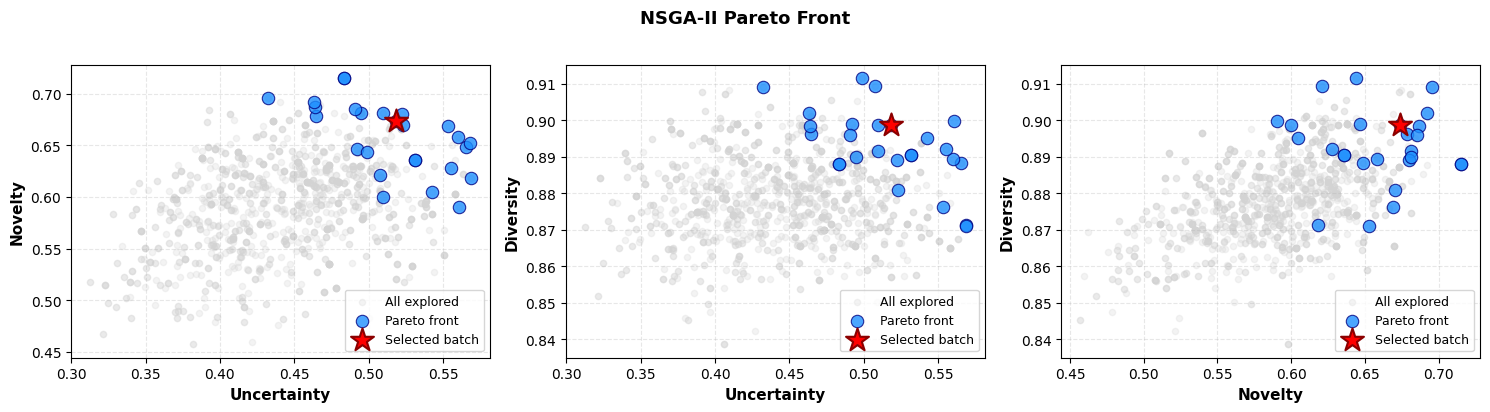

In [ ]:
F_final = np.array(F, dtype=float)
objs_all = np.array(all_objs, dtype=float)
objs_pareto = F_final[np.array(pareto, dtype=int)]
best_obj = np.array(obj, dtype=float)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    (0, 1, "Uncertainty", "Novelty"),
    (0, 2, "Uncertainty", "Diversity"),
    (1, 2, "Novelty", "Diversity"),
]

for ax, (i, j, xlabel, ylabel) in zip(axs, pairs):
    ax.scatter(objs_all[:, i], objs_all[:, j],
               c="lightgray", alpha=0.25, s=20, label="All explored")

    ax.scatter(objs_pareto[:, i], objs_pareto[:, j],
               c="dodgerblue", edgecolors="navy", linewidth=0.8,
               s=80, alpha=0.8, label="Pareto front", zorder=5)

    ax.scatter([best_obj[i]], [best_obj[j]],
               c="red", s=300, marker="*",
               edgecolors="darkred", linewidth=1.5,
               label="Selected batch", zorder=10)

    ax.set_xlabel(xlabel, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="best", fontsize=9)

plt.suptitle("NSGA-II Pareto Front", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### MOPSO

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

s=0
rounds=1
B=50
init_per_class=20
set_seed(s)

num_classes = len(label2id)
labeled_idx, unlabeled_idx = make_initial_split(train_df, num_classes, init_per_class=init_per_class, seed=s)

# initial pools (stratified)
labeled_idx, unlabeled_idx = make_initial_split(train_df, num_classes, init_per_class=init_per_class, seed=s)


model = make_model(num_classes).to(device)

L_df = train_df.loc[labeled_idx]
U_df = train_df.loc[unlabeled_idx]

L_loader = make_train_loader(L_df, batch_size=64)
V_loader = make_eval_loader(val_df, batch_size=128)

model, best_val_f1 = train_freeze_unfreeze(model, L_loader, V_loader)

B_eff = min(B, len(U_df))

prep = prepare_mopso_candidates(model, L_df, U_df, batch_size=B_eff, num_candidates=500)

batch_idx, best_obj, pareto_objs, pareto_batches, all_objs = mopso_select_batch(prep, swarm_size=40, iterations=30, seed=s, return_archive=True)

objs_all = np.array(all_objs, dtype=float)
objs_pareto = np.array(pareto_objs, dtype=float)


Starting Phase A: Training with frozen backbone (classifier head only)
[FROZEN] ep 00 | tr 2.0115 0.157 0.084 | va 1.8886 0.223 0.105
[FROZEN] ep 01 | tr 1.9420 0.200 0.172 | va 1.8768 0.235 0.117
[FROZEN] ep 02 | tr 2.0263 0.100 0.089 | va 1.8923 0.223 0.115

Starting Phase B: Fine-tuning all layers (unfrozen backbone)
[UNFROZE] ep 00 | tr 1.9921 0.136 0.114 | va 1.9696 0.130 0.092
[UNFROZE] ep 01 | tr 1.1958 0.714 0.715 | va 1.9657 0.190 0.115
[UNFROZE] ep 02 | tr 0.8937 0.850 0.845 | va 1.9689 0.229 0.132
[UNFROZE] ep 03 | tr 0.7296 0.857 0.859 | va 2.0139 0.258 0.155
[UNFROZE] ep 04 | tr 0.6365 0.900 0.895 | va 2.0110 0.288 0.173
[UNFROZE] ep 05 | tr 0.5487 0.929 0.930 | va 1.9479 0.315 0.187
[UNFROZE] ep 06 | tr 0.4701 0.971 0.973 | va 1.8561 0.345 0.206


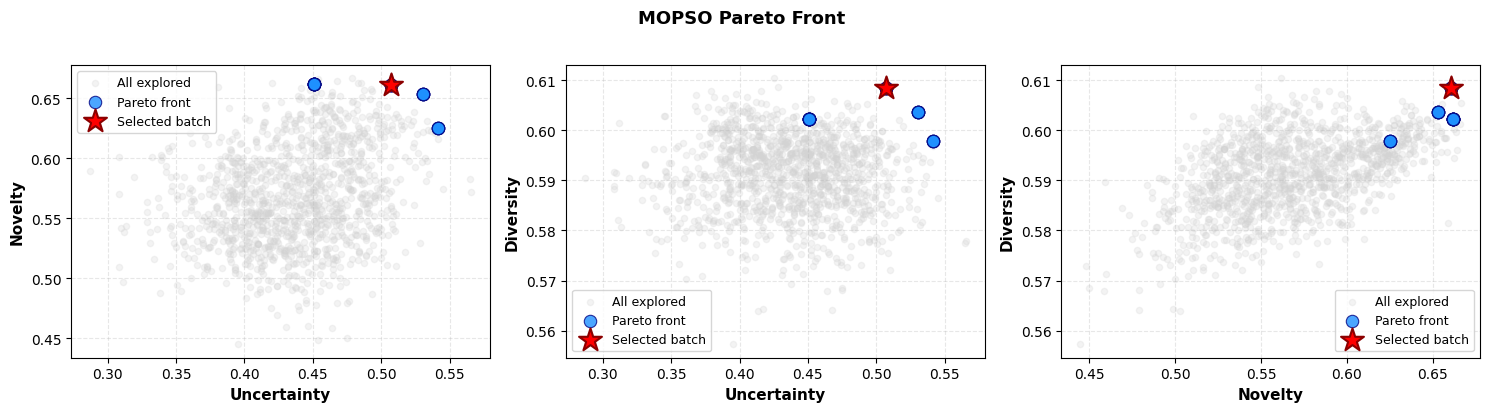

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    (0, 1, "Uncertainty", "Novelty"),
    (0, 2, "Uncertainty", "Diversity"),
    (1, 2, "Novelty", "Diversity")
]

for ax, (i, j, xlabel, ylabel) in zip(axs, pairs):
    # All explored points (light gray background)
    ax.scatter(objs_all[:, i], objs_all[:, j], c='lightgray', alpha=0.25, s=20, label='All explored')

    # Pareto front (blue with black edge)
    ax.scatter(objs_pareto[:, i], objs_pareto[:, j],c='dodgerblue', edgecolors='navy', linewidth=0.8, s=80, alpha=0.8, label='Pareto front', zorder=5)

    # Chosen solution (red star)
    ax.scatter([best_obj[i]], [best_obj[j]],
               c='red', s=300, marker='*',
               edgecolors='darkred', linewidth=1.5,
               label='Selected batch', zorder=10)

    ax.set_xlabel(xlabel, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=9)

plt.suptitle(f'MOPSO Pareto Front ', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Ablations

#### Greedy score: select_S


Starting Phase A: Training with frozen backbone (classifier head only)
[FROZEN] ep 00 | tr 1.9993 0.200 0.130 | va 2.1899 0.034 0.035
[FROZEN] ep 01 | tr 1.8912 0.250 0.181 | va 2.1113 0.046 0.037
[FROZEN] ep 02 | tr 1.9452 0.150 0.120 | va 2.0760 0.056 0.043

Starting Phase B: Fine-tuning all layers (unfrozen backbone)
[UNFROZE] ep 00 | tr 1.9337 0.243 0.231 | va 2.0463 0.102 0.090
[UNFROZE] ep 01 | tr 1.2952 0.643 0.638 | va 1.8937 0.260 0.184
[UNFROZE] ep 02 | tr 0.8374 0.814 0.816 | va 1.8096 0.350 0.223
[UNFROZE] ep 03 | tr 0.6752 0.907 0.901 | va 1.8242 0.372 0.241
[UNFROZE] ep 04 | tr 0.5247 0.979 0.980 | va 1.8294 0.365 0.240
[UNFROZE] ep 05 | tr 0.5643 0.929 0.934 | va 1.7798 0.391 0.252
[UNFROZE] ep 06 | tr 0.5239 0.921 0.919 | va 1.7055 0.426 0.270
[random | seed 42] round 00 | L=140 | best val F1=0.270

Starting Phase A: Training with frozen backbone (classifier head only)
[FROZEN] ep 00 | tr 0.6265 0.842 0.837 | va 1.5801 0.455 0.312
[FROZEN] ep 01 | tr 0.6753 0.853 0.851

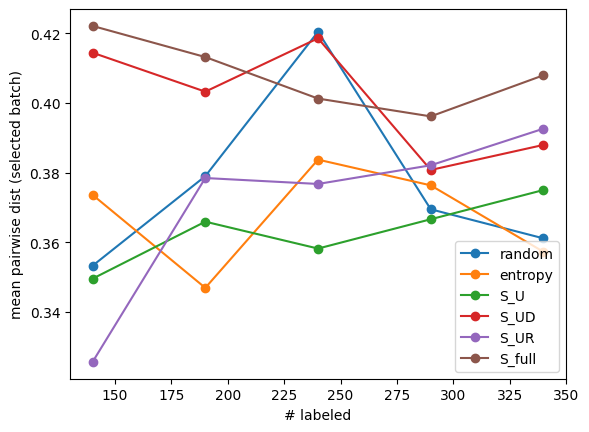

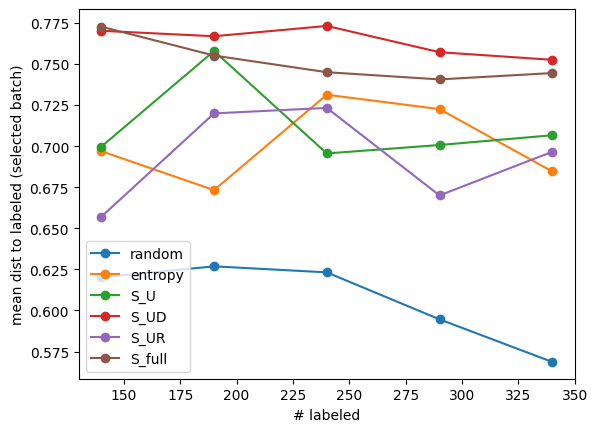

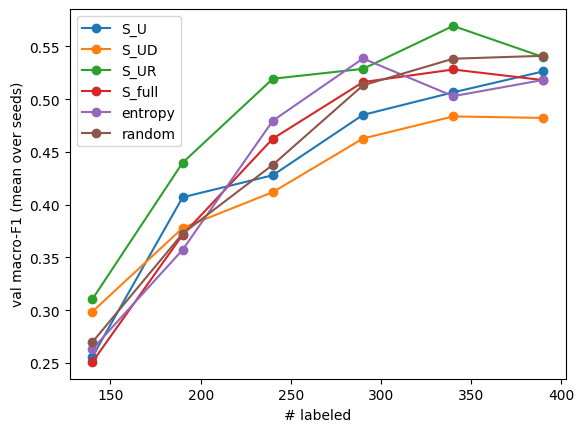

In [ ]:
import matplotlib.pyplot as plt
import ast

def run_experiments(train_df, val_df, seeds=(0), rounds=2, B=50, init_per_class=20):
    dfs = []
    for s in seeds:
        set_seed(s)
        dfs.append(run_active_learning("random", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))
        dfs.append(run_active_learning("entropy", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))
        dfs.append(run_active_learning("S_U", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))
        dfs.append(run_active_learning("S_UD", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))
        dfs.append(run_active_learning("S_UR", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))
        dfs.append(run_active_learning("S_full", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))

    return pd.concat(dfs, ignore_index=True)

results_df = run_experiments(train_df, val_df, seeds=(42,), rounds=5, B=50, init_per_class=20)
results_df.head()

summary = (results_df
           .groupby(["method", "labeled"], as_index=False)
           .agg(mean_f1=("val_macro_f1", "mean"),
                std_f1=("val_macro_f1", "std"),
                n=("val_macro_f1", "count"))
          )

def parse_counts(s):
    return {} if pd.isna(s) else ast.literal_eval(s)

tmp = results_df.copy()
tmp["counts"] = tmp["batch_class_counts_y"].apply(parse_counts)
counts_df = pd.json_normalize(tmp["counts"]).fillna(0)
counts_df["method"] = tmp["method"].values
counts_df["round"] = tmp["round"].values

# mean class counts per round per method (if multiple seeds)
mean_counts = counts_df.groupby(["method","round"]).mean()

for m in results_df.method.unique():
    sub = results_df[results_df.method==m].sort_values("labeled")
    plt.plot(sub["labeled"], sub["batch_mean_pairwise_dist"], marker="o", label=m)
plt.xlabel("# labeled"); plt.ylabel("mean pairwise dist (selected batch)")
plt.legend(); plt.show()

for m in results_df.method.unique():
    sub = results_df[results_df.method==m].sort_values("labeled")
    plt.plot(sub["labeled"], sub["batch_mean_dist_to_labeled"], marker="o", label=m)
plt.xlabel("# labeled"); plt.ylabel("mean dist to labeled (selected batch)")
plt.legend(); plt.show()

for method in summary["method"].unique():
    sub = summary[summary["method"] == method].sort_values("labeled")
    plt.plot(sub["labeled"], sub["mean_f1"], marker="o", label=method)
plt.xlabel("# labeled")
plt.ylabel("val macro-F1 (mean over seeds)")
plt.legend()
plt.show()

In [ ]:
mean_counts

0     1     2     4     5    6    3
method  round                                       
S_U     0      1.0   0.0   3.0   4.0  42.0  0.0  0.0
        1      1.0   2.0   6.0   4.0  36.0  0.0  1.0
        2      0.0   5.0   7.0   3.0  34.0  1.0  0.0
        3      3.0   0.0   2.0   5.0  37.0  1.0  2.0
        4      1.0   8.0   9.0   6.0  25.0  0.0  1.0
        5      0.0   0.0   0.0   0.0   0.0  0.0  0.0
S_UD    0      3.0   5.0  18.0   8.0  15.0  1.0  0.0
        1      2.0   1.0  15.0   3.0  29.0  0.0  0.0
        2      0.0   3.0  13.0   8.0  23.0  3.0  0.0
        3      0.0  18.0  16.0  11.0   0.0  2.0  3.0
        4      0.0   6.0   2.0   1.0  39.0  1.0  1.0
        5      0.0   0.0   0.0   0.0   0.0  0.0  0.0
S_UR    0      0.0   1.0   6.0  16.0  27.0  0.0  0.0
        1      0.0   2.0   8.0   7.0  31.0  1.0  1.0
        2      0.0  19.0  24.0   4.0   0.0  0.0  3.0
        3      0.0   4.0  10.0   7.0  27.0  0.0  2.0
        4      0.0  15.0  11.0   6.0  14.0  4.0  0.0
        5      0.0   0.0   0.0   0.0   0.0  0.0  0.0
S_full  0      2.0   1.0   4.0   1.0  42.0  0.0  0.0
        1      1.0   1.0   7.0   4.0  35.0  0.0  2.0
        2      1.0   6.0  15.0   6.0  20.0  1.0  1.0
        3      8.0   5.0  10.0   8.0  17.0  2.0  0.0
        4      3.0  10.0   8.0   2.0  24.0  0.0  3.0
        5      0.0   0.0   0.0   0.0   0.0  0.0  0.0
entropy 0      0.0   0.0  10.0   9.0  31.0  0.0  0.0
        1      1.0   2.0  12.0   4.0  28.0  2.0  1.0
        2      1.0   5.0   3.0   7.0  32.0  1.0  1.0
        3      6.0  12.0  10.0   6.0  14.0  2.0  0.0
        4      1.0  11.0  11.0  13.0   9.0  0.0  5.0
        5      0.0   0.0   0.0   0.0   0.0  0.0  0.0
random  0      3.0   1.0   6.0   5.0  35.0  0.0  0.0
        1      1.0   2.0   8.0   5.0  33.0  1.0  0.0
        2      1.0   4.0   6.0   4.0  33.0  0.0  2.0
        3      1.0   5.0   5.0   5.0  34.0  0.0  0.0
        4      0.0   0.0   5.0   7.0  37.0  0.0  1.0
        5      0.0   0.0   0.0   0.0   0.0  0.0  0.0

#### Varying M for NSGA2

In [ ]:
Ms = [50, 100, 250, 500, 1000]
dfs = []

# global entropy baseline once
dfs.append(run_active_learning("entropy", train_df, val_df, B=50, rounds=5, seed=42, init_per_class=20))

for M in Ms:
    dfs.append(run_active_learning("entropy_topM", train_df, val_df, B=50, rounds=5, seed=42, init_per_class=20, nsga_M=M))
    dfs.append(run_active_learning("nsga2", train_df, val_df, B=50, rounds=5, seed=42, init_per_class=20, nsga_M=M))

results_df = pd.concat(dfs, ignore_index=True)


Starting Phase A: Training with frozen backbone (classifier head only)
[FROZEN] ep 00 | tr 2.1151 0.107 0.052 | va 1.9385 0.229 0.100
[FROZEN] ep 01 | tr 1.9972 0.100 0.097 | va 2.0526 0.125 0.071
[FROZEN] ep 02 | tr 1.9385 0.207 0.157 | va 2.1133 0.085 0.059

Starting Phase B: Fine-tuning all layers (unfrozen backbone)
[UNFROZE] ep 00 | tr 1.9001 0.250 0.197 | va 2.1011 0.095 0.085
[UNFROZE] ep 01 | tr 1.1890 0.714 0.697 | va 2.0712 0.098 0.091
[UNFROZE] ep 02 | tr 0.9265 0.793 0.782 | va 1.9981 0.154 0.121
[UNFROZE] ep 03 | tr 0.9347 0.771 0.772 | va 1.9672 0.200 0.157
[UNFROZE] ep 04 | tr 0.5484 0.921 0.920 | va 1.9046 0.251 0.191
[UNFROZE] ep 05 | tr 0.5839 0.900 0.902 | va 1.8562 0.282 0.217
[UNFROZE] ep 06 | tr 0.6274 0.886 0.897 | va 1.7849 0.332 0.254
[entropy | seed 42] round 00 | L=140 | best val F1=0.254

Starting Phase A: Training with frozen backbone (classifier head only)
[FROZEN] ep 00 | tr 0.8444 0.747 0.751 | va 1.5140 0.483 0.298
[FROZEN] ep 01 | tr 0.6692 0.853 0.83

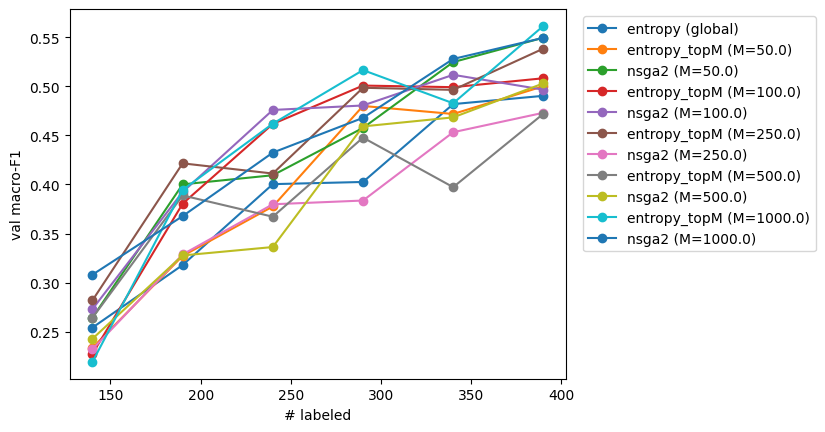

In [ ]:
# plot global entropy once
ent = results_df[results_df.method=="entropy"].sort_values("labeled")
plt.plot(ent["labeled"], ent["val_macro_f1"], marker="o", label="entropy (global)")

# plot per M
for M in sorted(results_df.get("nsga_M", pd.Series(dtype=int)).dropna().unique()):
    sub_e = results_df[(results_df.method=="entropy_topM") & (results_df.nsga_M==M)].sort_values("labeled")
    sub_n = results_df[(results_df.method=="nsga2") & (results_df.nsga_M==M)].sort_values("labeled")
    plt.plot(sub_e["labeled"], sub_e["val_macro_f1"], marker="o", label=f"entropy_topM (M={M})")
    plt.plot(sub_n["labeled"], sub_n["val_macro_f1"], marker="o", label=f"nsga2 (M={M})")

plt.xlabel("# labeled")
plt.ylabel("val macro-F1")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

In [ ]:
def aulc(df_):
    d = df_.sort_values("labeled")
    return float(np.trapz(d["val_macro_f1"].to_numpy(), d["labeled"].to_numpy())) if len(d) > 1 else np.nan

rows = []
for M in sorted(results_df["nsga_M"].dropna().unique()):
    e = results_df[(results_df.method=="entropy_topM") & (results_df.nsga_M==M)]
    n = results_df[(results_df.method=="nsga2") & (results_df.nsga_M==M)]

    rows.append({
        "M": int(M),
        "AULC_entropy_topM": aulc(e),
        "AULC_nsga2": aulc(n),
        "ΔAULC (nsga2 - entTopM)": aulc(n) - aulc(e),
        "finalF1_entropy_topM": float(e.sort_values("labeled").iloc[-1]["val_macro_f1"]),
        "finalF1_nsga2": float(n.sort_values("labeled").iloc[-1]["val_macro_f1"]),
        "ΔfinalF1": float(n.sort_values("labeled").iloc[-1]["val_macro_f1"] - e.sort_values("labeled").iloc[-1]["val_macro_f1"]),
        "mean_acq_s_entropy_topM": float(e["acq_seconds"].mean()) if "acq_seconds" in e.columns else np.nan,
        "mean_acq_s_nsga2": float(n["acq_seconds"].mean()) if "acq_seconds" in n.columns else np.nan,
    })

tbl = pd.DataFrame(rows).sort_values("M")
tbl

/tmp/ipython-input-3578576473.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(d["val_macro_f1"].to_numpy(), d["labeled"].to_numpy())) if len(d) > 1 else np.nan


,M,AULC_entropy_topM,AULC_nsga2,ΔAULC (nsga2 - entTopM),finalF1_entropy_topM,finalF1_nsga2,ΔfinalF1,mean_acq_s_entropy_topM,mean_acq_s_nsga2
0,50,101.170950,109.929037,8.758086,0.499998,0.549438,0.049440,34.746251,41.156305
1,100,110.484798,112.254176,1.769378,0.508144,0.496525,-0.011619,34.619082,41.818346
2,250,111.880093,94.901368,-16.978725,0.538320,0.473003,-0.065317,34.658042,43.144459
3,500,98.455509,98.220500,-0.235008,0.471975,0.502932,0.030957,34.454081,45.153182
4,1000,112.291527,111.228151,-1.063375,0.561434,0.549314,-0.012120,34.518144,50.027864


#### Test Pareto Choosers for NSGA2

In [ ]:
Ms = [100, 250]
choosers = ["sum", "ideal", "maximin", "adaptive"]
dfs = []

# baseline entropy_topM for each M (recommended)
for M in Ms:
    df = run_active_learning("entropy_topM", train_df, val_df, B=50, rounds=5, seed=42, init_per_class=20, nsga_M=M)
    df["tag"] = f"entropy_topM_M{M}"
    dfs.append(df)

for M in Ms:
    for ch in choosers:
        df = run_active_learning("nsga2", train_df, val_df,
                                 B=50, rounds=5, seed=42, init_per_class=20,
                                 nsga_M=M, nsga_pop=40, nsga_gens=25,
                                 nsga_chooser=ch)
        df["tag"] = f"nsga2_M{M}_{ch}"
        dfs.append(df)

res = pd.concat(dfs, ignore_index=True)


Starting Phase A: Training with frozen backbone (classifier head only)
[FROZEN] ep 00 | tr 2.1774 0.150 0.065 | va 1.9854 0.145 0.062
[FROZEN] ep 01 | tr 2.0622 0.200 0.169 | va 1.8921 0.216 0.087
[FROZEN] ep 02 | tr 1.9901 0.250 0.232 | va 1.8794 0.226 0.090

Starting Phase B: Fine-tuning all layers (unfrozen backbone)
[UNFROZE] ep 00 | tr 1.9577 0.193 0.162 | va 1.8928 0.229 0.127
[UNFROZE] ep 01 | tr 1.3319 0.643 0.643 | va 1.8999 0.256 0.168
[UNFROZE] ep 02 | tr 0.8544 0.893 0.896 | va 1.9039 0.283 0.192
[UNFROZE] ep 03 | tr 0.6851 0.914 0.909 | va 1.8775 0.334 0.221
[UNFROZE] ep 04 | tr 0.5734 0.964 0.961 | va 1.8330 0.373 0.246
[UNFROZE] ep 05 | tr 0.5408 0.893 0.887 | va 1.7990 0.397 0.262
[UNFROZE] ep 06 | tr 0.4525 0.971 0.970 | va 1.7317 0.427 0.275
[entropy_topM | seed 42] round 00 | L=140 | best val F1=0.275

Starting Phase A: Training with frozen backbone (classifier head only)
[FROZEN] ep 00 | tr 0.6622 0.842 0.839 | va 1.5461 0.502 0.338
[FROZEN] ep 01 | tr 0.6259 0.905

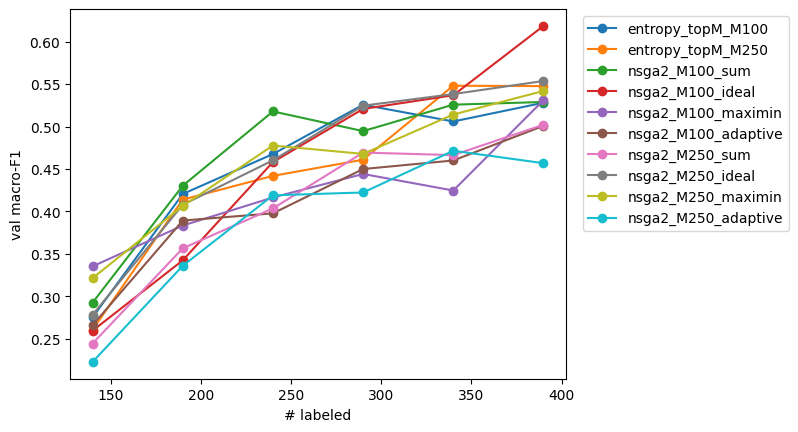

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
for tag in res["tag"].unique():
    sub = res[res["tag"]==tag].sort_values("labeled")
    plt.plot(sub["labeled"], sub["val_macro_f1"], marker="o", label=tag)
plt.xlabel("# labeled")
plt.ylabel("val macro-F1")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

In [ ]:
def aulc(df_):
    d = df_.sort_values("labeled")
    return float(np.trapz(d["val_macro_f1"].to_numpy(), d["labeled"].to_numpy()))

aulc_tbl = (res.groupby("tag")
              .apply(aulc)
              .reset_index(name="AULC")
              .sort_values("AULC", ascending=False))
aulc_tbl

/tmp/ipython-input-4194827077.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(d["val_macro_f1"].to_numpy(), d["labeled"].to_numpy()))
/tmp/ipython-input-4194827077.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aulc)


,tag,AULC
5,nsga2_M100_sum,118.952149
7,nsga2_M250_ideal,117.328208
0,entropy_topM_M100,116.058894
8,nsga2_M250_maximin,114.874522
3,nsga2_M100_ideal,114.849482
1,entropy_topM_M250,113.438333
4,nsga2_M100_maximin,105.073620
2,nsga2_M100_adaptive,104.004485
9,nsga2_M250_sum,103.436218
6,nsga2_M250_adaptive,99.406441


### Comprehensive AL Experiment

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt

def run_experiments(train_df, val_df, seeds=(42, 43, 44), rounds=10, B=50, init_per_class=20):
    dfs = []
    for s in seeds:
        set_seed(s)
        dfs.append(run_active_learning("random", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))
        dfs.append(run_active_learning("entropy", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))
        dfs.append(run_active_learning("entropy_topM", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))

        # pick strongest S baseline
        dfs.append(run_active_learning("S_full", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))

        # strongest NSGA config is now defaults inside run_active_learning (M=100, sum chooser)
        dfs.append(run_active_learning("nsga2", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))
        dfs.append(run_active_learning("mopso", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))

        dfs.append(run_active_learning("badge", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))
        dfs.append(run_active_learning("kcenters", train_df, val_df, init_per_class=init_per_class, B=B, rounds=rounds, seed=s))

    return pd.concat(dfs, ignore_index=True)

#results_df = run_experiments(train_df, val_df, seeds=(42, 43, 44), rounds=10, B=50, init_per_class=20)
#results_df = run_experiments(train_df, val_df, seeds=[42], rounds=2, B=50, init_per_class=20)

In [ ]:
results_df = run_experiments(train_df, val_df, seeds=[40], rounds=10, B=50, init_per_class=20)

# Save the results_df to a CSV file in Google Drive
output_path = '/content/drive/MyDrive/active_learning_results_seed40.csv'
results_df.to_csv(output_path, index=False)
print(f"Results saved to '{output_path}'")


Starting Phase A: Training with frozen backbone (classifier head only)
[FROZEN] ep 00 | tr 2.2071 0.150 0.077 | va 2.2218 0.027 0.029
[FROZEN] ep 01 | tr 2.0849 0.121 0.071 | va 2.1580 0.045 0.037
[FROZEN] ep 02 | tr 1.9884 0.150 0.133 | va 2.1372 0.056 0.042

Starting Phase B: Fine-tuning all layers (unfrozen backbone)
[UNFROZE] ep 00 | tr 1.9685 0.179 0.178 | va 2.1559 0.088 0.086
[UNFROZE] ep 01 | tr 1.3423 0.693 0.683 | va 2.1341 0.125 0.125
[UNFROZE] ep 02 | tr 0.9267 0.814 0.813 | va 2.1053 0.193 0.174
[UNFROZE] ep 03 | tr 0.7116 0.900 0.901 | va 2.0234 0.295 0.229
[UNFROZE] ep 04 | tr 0.6152 0.914 0.914 | va 1.9308 0.360 0.254
[UNFROZE] ep 05 | tr 0.5788 0.950 0.937 | va 1.8644 0.396 0.261
[UNFROZE] ep 06 | tr 0.5280 0.929 0.928 | va 1.7967 0.422 0.275
[random | seed 40] round 00 | L=140 | best val F1=0.275

Starting Phase A: Training with frozen backbone (classifier head only)
[FROZEN] ep 00 | tr 0.6951 0.842 0.845 | va 1.5604 0.495 0.311
[FROZEN] ep 01 | tr 0.7074 0.853 0.856

In [ ]:
import matplotlib.pyplot as plt

df_1 = pd.read_csv("/content/drive/MyDrive/active_learning_results_seed40.csv", index_col=False)
df_2 = pd.read_csv("/content/drive/MyDrive/active_learning_results_seed42.csv", index_col=False)
df_3 = pd.read_csv("/content/drive/MyDrive/active_learning_results_seed44.csv", index_col=False)
df_4 = pd.read_csv("/content/drive/MyDrive/active_learning_results_seed46.csv", index_col=False)
dfs = [df_1, df_2, df_3, df_4]
results_df = pd.concat(dfs, ignore_index=True)

output_path = '/content/drive/MyDrive/active_learning_results_df.csv'
results_df.to_csv(output_path, index=False)

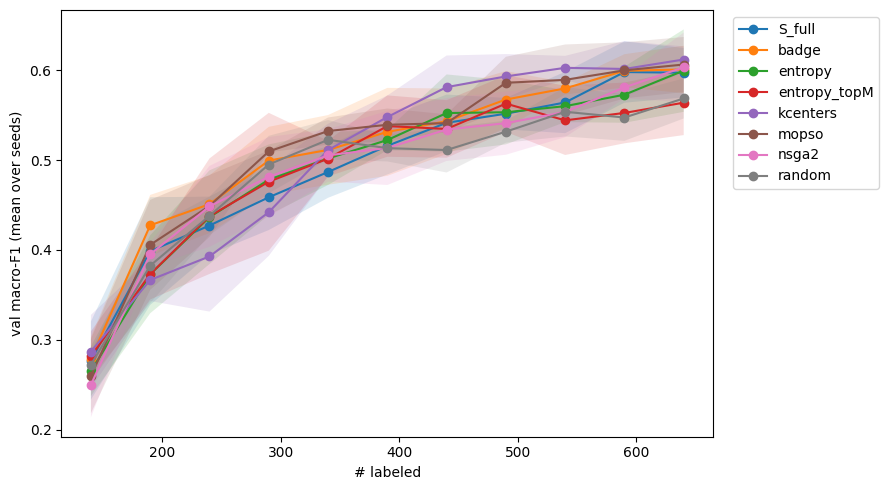

In [ ]:
summary = (results_df
           .groupby(["method", "labeled"], as_index=False)
           .agg(mean_f1=("val_macro_f1", "mean"),
                std_f1=("val_macro_f1", "std"),
                n=("val_macro_f1", "count")))

summary["sem"]  = summary["std_f1"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["sem"]

plt.figure(figsize=(9, 5))
for method in summary["method"].unique():
    sub = summary[summary["method"] == method].sort_values("labeled")
    x = sub["labeled"].to_numpy()
    y = sub["mean_f1"].to_numpy()
    e = sub["ci95"].fillna(0).to_numpy()
    plt.plot(x, y, marker="o", label=method)
    plt.fill_between(x, y - e, y + e, alpha=0.15)

plt.xlabel("# labeled")
plt.ylabel("val macro-F1 (mean over seeds)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
def aulc(df_one):
    d = df_one.sort_values("labeled")
    x = d["labeled"].to_numpy()
    y = d["val_macro_f1"].to_numpy()
    return np.trapz(y, x)

aulc_by_seed = (results_df
                .groupby(["method", "seed"])
                .apply(aulc)
                .reset_index(name="AULC"))

aulc_summary = (aulc_by_seed
                .groupby("method", as_index=False)
                .agg(mean_AULC=("AULC", "mean"),
                     std_AULC=("AULC", "std"),
                     n=("AULC", "count"))
                .sort_values("mean_AULC", ascending=False))

aulc_summary

/tmp/ipython-input-3730508105.py:5: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y, x)
/tmp/ipython-input-3730508105.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aulc)


,method,mean_AULC,std_AULC,n
5,mopso,259.318791,6.815186,4
1,badge,257.577713,11.847085,4
4,kcenters,254.470190,13.281604,4
2,entropy,249.172940,11.092742,4
6,nsga2,249.051457,10.998632,4
0,S_full,249.025893,12.327225,4
3,entropy_topM,247.204972,12.302740,4
7,random,245.845177,8.090691,4


In [ ]:
time_summary = (results_df
                .groupby("method", as_index=False)
                .agg(mean_acq_s=("acq_seconds", "mean"),
                     std_acq_s=("acq_seconds", "std"),
                     n=("acq_seconds", "count"))
                .sort_values("mean_acq_s"))

time_summary

,method,mean_acq_s,std_acq_s,n
7,random,0.000923,0.000061,40
2,entropy,33.506643,1.338249,40
3,entropy_topM,33.585916,1.149520,40
1,badge,34.427335,0.426876,40
4,kcenters,37.349818,0.348663,40
6,nsga2,43.281941,0.480381,40
5,mopso,44.206403,0.485394,40
0,S_full,70.841891,1.309305,40


In [ ]:
metric_cols = [
    "batch_mean_entropy", "batch_median_entropy",
    "batch_mean_dist_to_labeled", "batch_min_dist_to_labeled",
    "batch_mean_pairwise_dist", "batch_mean_nn_dist",
]

avail = [c for c in metric_cols if c in results_df.columns]
metric_summary = (results_df
                  .groupby("method", as_index=False)[avail]
                  .agg(["mean", "std"]))
metric_summary

# # or, optionally
# metric_summary = (results_df
#                   .groupby("method", as_index=False)
#                   .agg(**{f"{c}_mean": (c, "mean") for c in avail},
#                        **{f"{c}_std":  (c, "std")  for c in avail}))
# metric_summary

method batch_mean_entropy           batch_median_entropy            \
                              mean       std                 mean       std   
0        S_full           1.626637  0.102556             1.616387  0.105569   
1         badge           1.394137  0.118177             1.433939  0.127497   
2       entropy           1.757028  0.084088             1.749240  0.085323   
3  entropy_topM           1.760409  0.085133             1.753959  0.087128   
4      kcenters           1.485193  0.119657             1.519367  0.118591   
5         mopso           1.652326  0.106139             1.642330  0.110474   
6         nsga2           1.703601  0.100649             1.700157  0.101357   
7        random           0.971875  0.237171             0.971522  0.268695   

  batch_mean_dist_to_labeled           batch_min_dist_to_labeled            \
                        mean       std                      mean       std   
0                   0.723345  0.024272                  0.694953  0.024130   
1                   0.653830  0.020866                  0.468989  0.072351   
2                   0.693811  0.021541                  0.537470  0.070299   
3                   0.690794  0.020570                  0.523038  0.069396   
4                   0.750804  0.029619                  0.737556  0.025248   
5                   0.701034  0.020899                  0.559269  0.065503   
6                   0.709475  0.026550                  0.574544  0.078332   
7                   0.594589  0.025333                  0.407347  0.050726   

  batch_mean_pairwise_dist           batch_mean_nn_dist            
                      mean       std               mean       std  
0                 0.393730  0.013022           0.263394  0.015179  
1                 0.403046  0.011804           0.252157  0.013128  
2                 0.370716  0.016143           0.241854  0.015025  
3                 0.373580  0.020225           0.243901  0.019435  
4                 0.417532  0.022668           0.300476  0.019272  
5                 0.398815  0.012101           0.261462  0.016089  
6                 0.393246  0.012766           0.257783  0.012747  
7                 0.383138  0.015799           0.211150  0.012836

In [ ]:
nsga_df = results_df[results_df["method"] == "nsga2"].copy()

nsga_obj_cols = ["nsga_obj_unc", "nsga_obj_cov", "nsga_obj_div", "nsga_wU", "nsga_wC", "nsga_wD"]
nsga_avail = [c for c in nsga_obj_cols if c in nsga_df.columns]

nsga_summary = (nsga_df
                .groupby(["round"], as_index=False)[nsga_avail]
                .mean())
nsga_summary

,round,nsga_obj_unc,nsga_obj_cov,nsga_obj_div
0,0,0.545862,0.693383,0.886148
1,1,0.533592,0.684630,0.898900
2,2,0.499093,0.693022,0.900368
3,3,0.500603,0.688498,0.894468
4,4,0.488817,0.721080,0.894863
5,5,0.503921,0.712441,0.885115
6,6,0.512428,0.709665,0.881423
7,7,0.523980,0.729034,0.875469
8,8,0.514335,0.722046,0.880223
9,9,0.522849,0.706145,0.877049
